In [1]:
# Setup environment
!pip -q install prophet tensorflow scikit-learn


In [2]:
!pip uninstall -y prophet
!pip install -U prophet

Found existing installation: prophet 1.1.5
Uninstalling prophet-1.1.5:
  Successfully uninstalled prophet-1.1.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 51.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

import prophet
print("Prophet:", prophet.__version__)

NumPy : 2.5.2
Pandas: 3.0.5
Prophet: 1.4.0


# Prediksi Harga Komoditas Pertanian (Prophet + LSTM)
Implementasi end-to-end berdasarkan metodologi: **Data → Preprocessing → Prophet → LSTM → Evaluasi**.

- Siapkan file CSV berformat deret waktu minimal dengan kolom:
  - `date` (YYYY-MM-DD atau YYYY/MM/DD)
  - `price` (angka)
- Frekuensi: harian atau mingguan. Notebook ini otomatis menyetel frekuensi dan melakukan resampling bila perlu.
- Jika belum ada data, gunakan **Generator Data Sintetis** untuk mencoba alur lengkap.

---


## 1) Import Library & Helper

In [4]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Prophet
from prophet import Prophet

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Helper metrics
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def train_val_test_split(df, val_size=0.1, test_size=0.1):
    n = len(df)
    n_test = int(n * test_size)
    n_val = int(n * val_size)
    n_train = n - n_val - n_test
    return n_train, n_val, n_test

def plot_actual_vs_pred(dates, actual, preds, title):
    plt.figure(figsize=(12,5))
    plt.plot(dates, actual, label='Actual')
    plt.plot(dates, preds, label='Predicted')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

## 2) Opsi Data
Pilih salah satu:
1. **Upload CSV manual** (widget Colab)  
2. **Ambil dari Google Drive** (mount drive & path file)  
3. **Generate data sintetis** (untuk uji cepat)


In [ ]:
# Opsi 1: Upload Manual
# Jalankan sel ini untuk mengunggah CSV dari komputer lokal ke Colab.
# Pastikan CSV memiliki kolom: date, price
from google.colab import files

def upload_csv():
    uploaded = files.upload()
    for fn in uploaded.keys():
        print('File uploaded:', fn)
    return list(uploaded.keys())[0] if uploaded else None

# Contoh pemakaian:
# csv_path = upload_csv()  # uncomment untuk menggunakan
csv_path = None  # default None; ganti setelah upload


In [ ]:
# Opsi 2: Google Drive
from google.colab import drive
# drive.mount('/content/drive')  # uncomment untuk mount
# csv_path = '/content/drive/MyDrive/data/harga_beras.csv'


In [5]:
# === Opsi 3: Generator Data Sintetis ===
# Membuat data harga mingguan 5 tahun dengan tren + musiman + noise.
def generate_synthetic_weekly(start='2020-01-05', periods=5*52, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start=start, periods=periods, freq='W-SUN')
    trend = np.linspace(100, 160, periods)
    season = 10 * np.sin(2 * np.pi * np.arange(periods) / 52)
    seasonal_shock = np.zeros(periods)
    for year in range(5):
        base = year*52 + 16
        if base < periods:
            seasonal_shock[base:base+2] += 12
    noise = rng.normal(0, 3, periods)
    price = trend + season + seasonal_shock + noise
    df = pd.DataFrame({'date': dates, 'price': price})
    return df
csv_path = None

use_synthetic = True if (csv_path is None) else False

if use_synthetic:
    df_raw = generate_synthetic_weekly()
else:
    df_raw = pd.read_csv(csv_path)

df_raw.head()


,date,price
0,2020-01-05,100.914151
1,2020-01-12,98.317075
2,2020-01-19,105.107831
3,2020-01-26,107.062724
4,2020-02-02,99.720767


## 3) Prapemrosesan
- Parse tanggal & sort
- Hilangkan duplikasi
- Tangani missing values/outlier sederhana
- Resampling ke frekuensi reguler (H/W) bila perlu
- Buat fitur tambahan (lag, rolling mean)


In [6]:

df = df_raw.copy()
if 'date' not in df.columns or 'price' not in df.columns:
    raise ValueError("CSV harus memiliki kolom 'date' dan 'price'")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').drop_duplicates(subset=['date']).reset_index(drop=True)

df = df.set_index('date').asfreq('D')
df['price'] = df['price'].interpolate(method='time')

q1, q3 = df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
df['price'] = df['price'].clip(lower, upper)

df = df.reset_index()
print(df.head(), df.tail(), len(df))

        date       price
0 2020-01-05  100.914151
1 2020-01-06  100.543140
2 2020-01-07  100.172129
3 2020-01-08   99.801118
4 2020-01-09   99.430108            date       price
1809 2024-12-18  155.986385
1810 2024-12-19  155.657275
1811 2024-12-20  155.328165
1812 2024-12-21  154.999056
1813 2024-12-22  154.669946 1814


In [7]:

df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

df['roll_mean_7'] = df['price'].rolling(window=7, min_periods=1).mean()
df['roll_std_7']  = df['price'].rolling(window=7, min_periods=1).std().fillna(0)
df['roll_mean_30'] = df['price'].rolling(window=30, min_periods=1).mean()
df['roll_std_30']  = df['price'].rolling(window=30, min_periods=1).std().fillna(0)

for l in [1, 7, 14]:
    df[f'lag_{l}'] = df['price'].shift(l)

df = df.dropna().reset_index(drop=True)
df.head()

,date,price,dayofweek,month,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30,lag_1,lag_7,lag_14
0,2020-01-19,105.107831,6,1,102.197507,2.095673,100.820497,2.018121,104.137723,98.317075,100.914151
1,2020-01-20,105.387101,0,1,103.068924,1.946750,101.105909,2.259349,105.107831,99.287183,100.543140
2,2020-01-21,105.666372,1,1,103.841649,1.702975,101.374172,2.451330,105.387101,100.257291,100.172129
3,2020-01-22,105.945642,2,1,104.515684,1.403149,101.628143,2.610855,105.666372,101.227399,99.801118
4,2020-01-23,106.224912,3,1,105.091028,1.083461,101.870078,2.747724,105.945642,102.197507,99.430108


## 4) Model Prophet
- Fit Prophet pada kolom `ds` (tanggal) dan `y` (harga)
- Forecast ke horizon tertentu (misal 30 hari)
- Ambil komponen/ramalan Prophet sebagai **fitur tambahan** nantinya


In [8]:
df_prophet = df[['date','price']].rename(columns={'date':'ds','price':'y'})

n_train, n_val, n_test = train_val_test_split(df_prophet, val_size=0.1, test_size=0.1)
train_p = df_prophet.iloc[:n_train]
val_p   = df_prophet.iloc[n_train:n_train+n_val]
test_p  = df_prophet.iloc[n_train+n_val:]

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
m.fit(train_p)

future = pd.concat([val_p[['ds']], test_p[['ds']]], axis=0)
future = future.drop_duplicates().sort_values('ds').reset_index(drop=True)

forecast = m.predict(future)
prophet_pred = forecast[['ds','yhat','trend','weekly','yearly']].copy()
prophet_pred.rename(columns={'ds':'date'}, inplace=True)

df_feat = pd.merge(df, prophet_pred, on='date', how='left')
df_feat.head()

,date,price,dayofweek,month,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30,lag_1,lag_7,lag_14,yhat,trend,weekly,yearly
0,2020-01-19,105.107831,6,1,102.197507,2.095673,100.820497,2.018121,104.137723,98.317075,100.914151,NaN,NaN,NaN,NaN
1,2020-01-20,105.387101,0,1,103.068924,1.946750,101.105909,2.259349,105.107831,99.287183,100.543140,NaN,NaN,NaN,NaN
2,2020-01-21,105.666372,1,1,103.841649,1.702975,101.374172,2.451330,105.387101,100.257291,100.172129,NaN,NaN,NaN,NaN
3,2020-01-22,105.945642,2,1,104.515684,1.403149,101.628143,2.610855,105.666372,101.227399,99.801118,NaN,NaN,NaN,NaN
4,2020-01-23,106.224912,3,1,105.091028,1.083461,101.870078,2.747724,105.945642,102.197507,99.430108,NaN,NaN,NaN,NaN


### Evaluasi Sementara: Prophet

Prophet — RMSE: 3.295 | MAE: 2.611


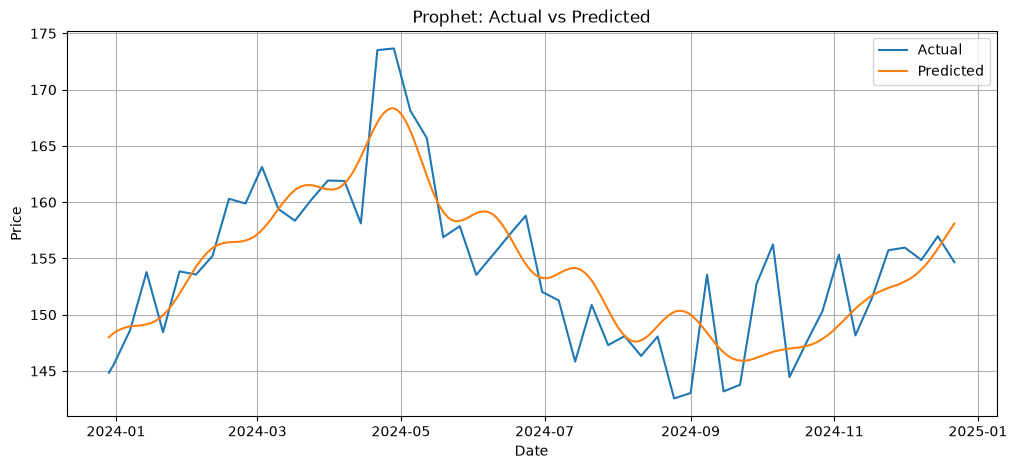

In [9]:
eval_range = pd.merge(
    df[['date','price']],
    prophet_pred[['date','yhat']],
    on='date', how='inner'
).sort_values('date')

p_rmse = rmse(eval_range['price'], eval_range['yhat'])
p_mae  = mae(eval_range['price'], eval_range['yhat'])
print("Prophet — RMSE: %.3f | MAE: %.3f" % (p_rmse, p_mae))

plot_actual_vs_pred(eval_range['date'], eval_range['price'], eval_range['yhat'], "Prophet: Actual vs Predicted")

## 5) Model LSTM (Only) dan Kombinasi (Prophet + LSTM)
- Siapkan data supervised (window/sequences) untuk LSTM
- **Model Only LSTM**: pakai `price` historis (dan fitur teknis opsional)
- **Model Kombinasi**: tambahkan `yhat`/komponen Prophet sebagai fitur tambahan


In [15]:
feature_cols_base = ['price','roll_mean_7','roll_std_7','roll_mean_30','roll_std_30',
                     'lag_1','lag_7','lag_14']
feature_cols_prophet = feature_cols_base + ['yhat','trend','weekly','yearly']

df_model = df_feat.dropna(subset=['yhat']).copy().reset_index(drop=True)

dates_model = df_model['date']
n_train_m, n_val_m, n_test_m = train_val_test_split(df_model, val_size=0.1, test_size=0.1)
train_idx = slice(0, n_train_m)
val_idx   = slice(n_train_m, n_train_m+n_val_m)
test_idx  = slice(n_train_m+n_val_m, None)

def make_sequences(data, feature_cols, target_col='price', lookback=30, horizon=1):
    X, y, dts = [], [], []
    values = data[feature_cols + [target_col]].values
    for i in range(lookback, len(values) - horizon + 1):
        X.append(values[i-lookback:i, :-1])
        y.append(values[i + horizon - 1, -1])
        dts.append(data['date'].iloc[i + horizon - 1])
    return np.array(X), np.array(y), np.array(dts)

def fit_lstm(X_tr, y_tr, X_va, y_va, units=50, dropout=0.2, epochs=50, batch_size=64):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(X_tr.shape[1], X_tr.shape[2])),
        Dropout(dropout),
        LSTM(units),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    cb = [
        EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-5, monitor='val_loss')
    ]
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs, batch_size=batch_size, verbose=1, callbacks=cb)
    return model

def scale_by_split(df_in, cols, train_idx, val_idx, test_idx):
    scaler = MinMaxScaler()
    train = df_in.iloc[train_idx].copy()
    val   = df_in.iloc[val_idx].copy()
    test  = df_in.iloc[test_idx].copy()
    scaler.fit(train[cols])
    train[cols] = scaler.transform(train[cols])
    val[cols]   = scaler.transform(val[cols])
    test[cols]  = scaler.transform(test[cols])
    return train, val, test, scaler

### 5.1 LSTM Only

(258, 30, 8) (6, 30, 8) (6, 30, 8)
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0738 - val_loss: 0.0675 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0389 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0267 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0254 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0197 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0241 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0176 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0197 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0169 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/st

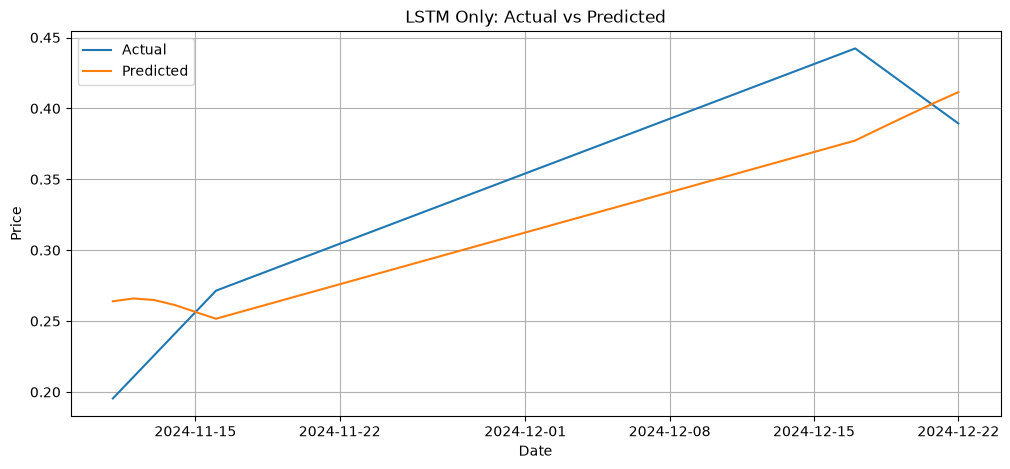

In [11]:
lookback = 30
horizon  = 1

train_l, val_l, test_l, scaler_base = scale_by_split(df_model, feature_cols_base, train_idx, val_idx, test_idx)

X_train, y_train, d_train = make_sequences(train_l, feature_cols_base, 'price', lookback, horizon)
X_val,   y_val,   d_val   = make_sequences(val_l, feature_cols_base, 'price', lookback, horizon)
X_test,  y_test,  d_test  = make_sequences(test_l, feature_cols_base, 'price', lookback, horizon)

print(X_train.shape, X_val.shape, X_test.shape)

model_lstm = fit_lstm(X_train, y_train, X_val, y_val, units=50, dropout=0.2, epochs=50, batch_size=64)

X_eval = np.concatenate([X_val, X_test], axis=0)
y_eval = np.concatenate([y_val, y_test], axis=0)
d_eval = np.concatenate([d_val, d_test], axis=0)

pred_lstm = model_lstm.predict(X_eval).ravel()
lstm_rmse = rmse(y_eval, pred_lstm)
lstm_mae  = mae(y_eval, pred_lstm)
print("LSTM Only — RMSE: %.3f | MAE: %.3f" % (lstm_rmse, lstm_mae))

plot_actual_vs_pred(d_eval, y_eval, pred_lstm, "LSTM Only: Actual vs Predicted")

### 5.2 Prophet + LSTM (Kombinasi)
Menambahkan fitur `yhat`, `trend`, `weekly`, `yearly` dari Prophet sebagai input LSTM.


(258, 30, 12) (6, 30, 12) (6, 30, 12)
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 360ms/step - loss: 0.1396 - val_loss: 0.0574 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0593 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0282 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0344 - val_loss: 9.6469e-04 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0236 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0259 - val_loss: 9.3022e-04 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0200 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0185 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0181 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━

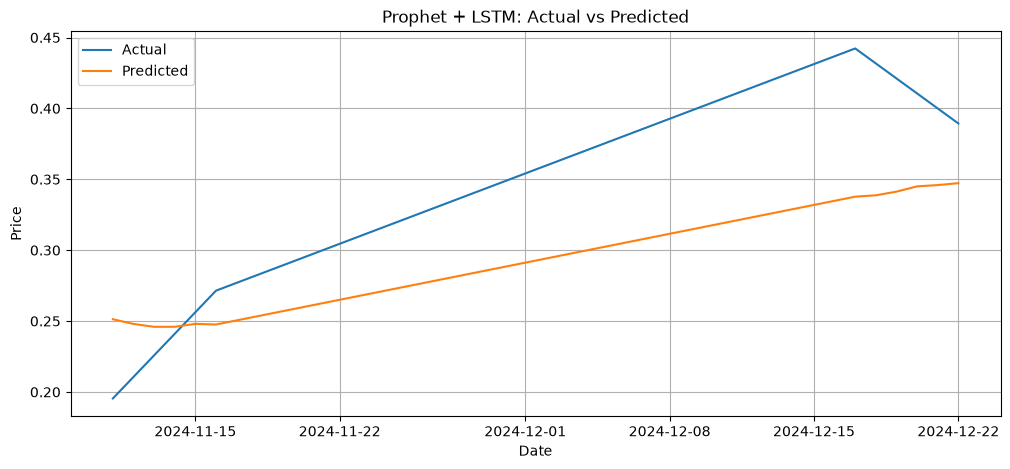

In [12]:
train_c, val_c, test_c, scaler_combo = scale_by_split(df_model, feature_cols_prophet, train_idx, val_idx, test_idx)

X_train_c, y_train_c, d_train_c = make_sequences(train_c, feature_cols_prophet, 'price', lookback, horizon)
X_val_c,   y_val_c,   d_val_c   = make_sequences(val_c, feature_cols_prophet, 'price', lookback, horizon)
X_test_c,  y_test_c,  d_test_c  = make_sequences(test_c, feature_cols_prophet, 'price', lookback, horizon)

print(X_train_c.shape, X_val_c.shape, X_test_c.shape)

model_combo = fit_lstm(X_train_c, y_train_c, X_val_c, y_val_c, units=50, dropout=0.2, epochs=50, batch_size=64)

X_eval_c = np.concatenate([X_val_c, X_test_c], axis=0)
y_eval_c = np.concatenate([y_val_c, y_test_c], axis=0)
d_eval_c = np.concatenate([d_val_c, d_test_c], axis=0)

pred_combo = model_combo.predict(X_eval_c).ravel()
combo_rmse = rmse(y_eval_c, pred_combo)
combo_mae  = mae(y_eval_c, pred_combo)
print("Prophet + LSTM — RMSE: %.3f | MAE: %.3f" % (combo_rmse, combo_mae))

plot_actual_vs_pred(d_eval_c, y_eval_c, pred_combo, "Prophet + LSTM: Actual vs Predicted")

## 6) Ringkasan Hasil

In [16]:
summary = pd.DataFrame({
    'Model': ['Prophet', 'LSTM Only', 'Prophet + LSTM'],
    'RMSE': [p_rmse, lstm_rmse, combo_rmse],
    'MAE':  [p_mae,  lstm_mae,  combo_mae]
})
print(summary)
summary

            Model      RMSE       MAE
0         Prophet  3.295139  2.611090
1       LSTM Only  0.038828  0.032053
2  Prophet + LSTM  0.058110  0.049118


,Model,RMSE,MAE
0,Prophet,3.295139,2.611090
1,LSTM Only,0.038828,0.032053
2,Prophet + LSTM,0.058110,0.049118
